In [27]:
# https://riskfolio-lib.readthedocs.io/en/latest/install.html
from riskfolio import RiskFunctions
from riskfolio import PlotFunctions
import pandas as pd

In [28]:
ret_df = pd.read_csv('../data/processed_returns.csv', index_col=0, parse_dates=True)
ret_df = ret_df / 100
ret_df.head()

,SPY,AGG,PE,NPI
Date,,,,
2000-03-31,0.026433,NaN,0.070000,0.032000
2000-06-30,-0.031599,NaN,-0.099859,0.021881
2000-09-30,-0.008916,NaN,-0.222216,0.020881
2000-12-31,-0.083796,NaN,-0.100503,0.014821
2001-03-31,-0.108115,NaN,0.013531,-0.037275


In [29]:
# Calculate CVaR using historical method
# https://riskfolio-lib.readthedocs.io/en/latest/risk.html#RiskFunctions.CVaR_Hist
RiskFunctions.CVaR_Hist(ret_df['SPY'], alpha=0.05)

0.17854325923442127

In [30]:
# risk contribution
# https://riskfolio-lib.readthedocs.io/en/latest/risk.html#RiskFunctions.Risk_Contribution
w = pd.Series([0.4, 0.2, 0.25, 0.15], index=['SPY', 'AGG', 'PE', 'NPI'])
Risk_Contribution = RiskFunctions.Risk_Contribution(
    w, ret_df, cov=None, rm='CVaR', rf=0, alpha=0.05, a_sim=100, beta=None, b_sim=None,
    kappa=0.3, kappa_g=None, solver='CLARABEL'
)

Risk_Contribution

array([0.05734692, 0.00019029, 0.07017125, 0.03067411])

In [31]:
# risk margin
# https://riskfolio-lib.readthedocs.io/en/latest/risk.html#RiskFunctions.Risk_Margin
Risk_Margin = RiskFunctions.Risk_Margin(
    w, ret_df, cov=None, rm='CVaR', rf=0, alpha=0.05, a_sim=100, beta=None, b_sim=None,
    kappa=0.3, kappa_g=None, solver='CLARABEL'
)

Risk_Margin

array([0.14336729, 0.00095143, 0.280685  , 0.20449404])

<Axes: title={'center': 'Risk (Conditional Value at Risk $\\alpha = $5.00%) Contribution per Asset'}>

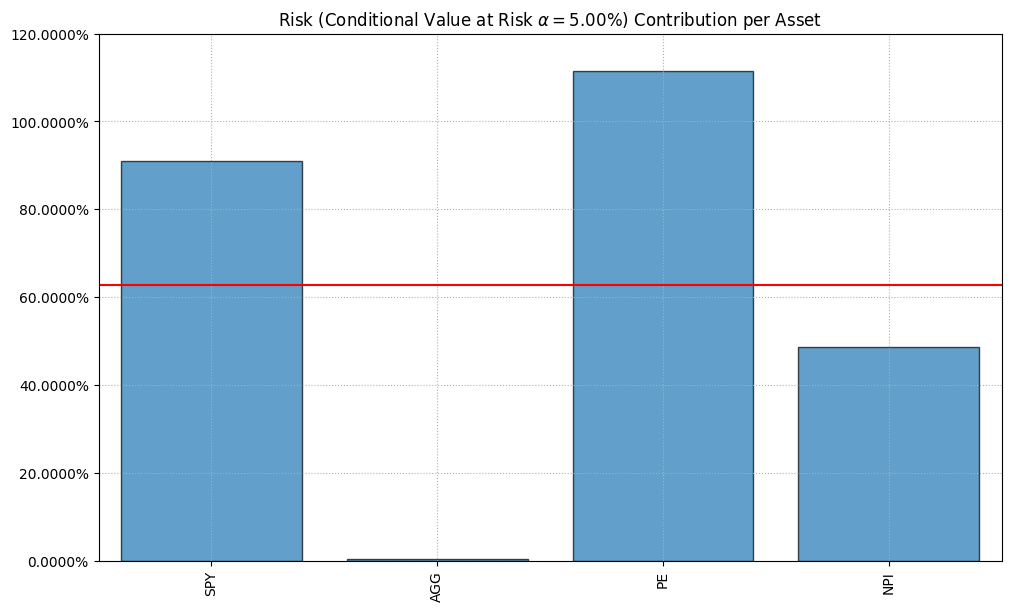

In [32]:
# plot_risk_con
# https://riskfolio-lib.readthedocs.io/en/latest/plot.html#PlotFunctions.plot_series
PlotFunctions.plot_risk_con(
    w, ret_df, cov=None, asset_classes=None, classes_col=None, rm='CVaR', rf=0, alpha=0.05,
    a_sim=100, beta=None, b_sim=None, kappa=0.3, kappa_g=None, solver='CLARABEL',
    percentage=False, erc_line=True, color='tab:blue', erc_linecolor='r', height=6, width=10,
    t_factor=252, ax=None
)